In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import tensorflow as tf
import numpy as np
import os

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-06-24 11:30:50.257521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782300650.427017      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782300650.474223      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782300650.855638      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782300650.855684      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782300650.855687      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import os

# Find the folder that contains all 5 sign folders, wherever Kaggle put it
TARGET = {"Hello", "Yes", "No", "ILoveYou", "Water"}

DATA_DIR = None
for root, dirs, files in os.walk("/kaggle/input"):
    if TARGET.issubset(set(dirs)):
        DATA_DIR = root
        break

print("DATA_DIR:", DATA_DIR)
print("\nImage counts:")
for d in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, d)
    if os.path.isdir(full):
        print(f"  {d:10s}: {len(os.listdir(full))} images")

DATA_DIR: /kaggle/input/datasets/tanishsam/asl-5-signs/data/train

Image counts:
  Hello     : 301 images
  ILoveYou  : 302 images
  No        : 302 images
  Water     : 285 images
  Yes       : 290 images


In [4]:
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
EPOCHS     = 25
VAL_SPLIT  = 0.2

MODEL_OUT = "/kaggle/working/sign_model.keras"
NAMES_OUT = "/kaggle/working/class_names.pkl"

In [5]:
# CELL 4 — Load data with a PROPER shuffled split
import tensorflow as tf
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE

# image_dataset_from_directory shuffles the file list (using the seed)
# BEFORE splitting -> train & validation both get a random mix of all
# signs AND all backgrounds/rounds.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset="training",
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int",
)
valid_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset="validation",
    seed=42,                       # SAME seed -> no overlap with training
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int",
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Scale pixels 0-255 -> 0-1 (model expects 0-1, which matches the app)
normalize = layers.Rescaling(1./255)

# Light augmentation, TRAINING ONLY
augment = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])

train_ds = (train_ds
    .map(lambda x, y: (augment(normalize(x), training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))
valid_ds = (valid_ds
    .map(lambda x, y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

Found 1480 files belonging to 5 classes.
Using 1184 files for training.


I0000 00:00:1782300683.246940      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782300683.253487      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1480 files belonging to 5 classes.
Using 296 files for validation.
Classes: ['Hello', 'ILoveYou', 'No', 'Water', 'Yes']


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(*IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,861 (8.37 MB)

 Trainable params: 2,192,901 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_OUT, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(train_ds, validation_data=valid_ds,
                    epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/25


I0000 00:00:1782300865.039917     134 service.cc:152] XLA service 0x7e6c90003f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782300865.039988     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782300865.039996     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782300865.811074     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


 8/37 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2936 - loss: 2.6287

I0000 00:00:1782300872.613908     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4087 - loss: 1.9518
Epoch 1: val_accuracy improved from None to 0.16892, saving model to /kaggle/working/sign_model.keras

Epoch 1: finished saving model to /kaggle/working/sign_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.5127 - loss: 1.4804 - val_accuracy: 0.1689 - val_loss: 2.8625 - learning_rate: 0.0010
Epoch 2/25
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6450 - loss: 0.9802
Epoch 2: val_accuracy did not improve from 0.16892
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6875 - loss: 0.8969 - val_accuracy: 0.1689 - val_loss: 7.3235 - learning_rate: 0.0010
Epoch 3/25
36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7077 - loss: 0.7248
Epoch 3: val_accuracy did not improve from 0.16892
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7306 - loss: 0.7030 - val_accuracy: 0.1689 - val_loss: 11.6344 - learning_rate: 0.0010
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy

In [12]:
# CELL 7 — Diagnostic
import numpy as np
all_true, all_pred = [], []
for imgs, lbls in valid_ds:
    p = model.predict(imgs, verbose=0)
    all_pred.extend(np.argmax(p, axis=1))
    all_true.extend(lbls.numpy())
all_true, all_pred = np.array(all_true), np.array(all_pred)

print("Overall accuracy:", round(np.mean(all_pred==all_true)*100, 1), "%\n")
print("Per-class accuracy:")
for i, name in enumerate(class_names):
    m = all_true == i
    acc = np.mean(all_pred[m] == all_true[m])*100 if m.sum() else 0
    print(f"  {name:10s}: {acc:.1f}%")
print("\nWhat it predicts (should spread across all 5):")
print({class_names[i]: int((all_pred==i).sum()) for i in range(len(class_names))})

Overall accuracy: 93.2 %

Per-class accuracy:
  Hello     : 100.0%
  ILoveYou  : 90.0%
  No        : 81.0%
  Water     : 100.0%
  Yes       : 95.7%

What it predicts (should spread across all 5):
{'Hello': 57, 'ILoveYou': 54, 'No': 53, 'Water': 64, 'Yes': 68}


In [9]:
import pickle
with open(NAMES_OUT, "wb") as f:
    pickle.dump(class_names, f)

print("Saved files:")
for f in os.listdir("/kaggle/working"):
    print(" ", f)
print("\nDownload sign_model.keras + class_names.pkl from the Output panel.")

Saved files:
  .virtual_documents
  sign_model.keras
  class_names.pkl

Download sign_model.keras + class_names.pkl from the Output panel.


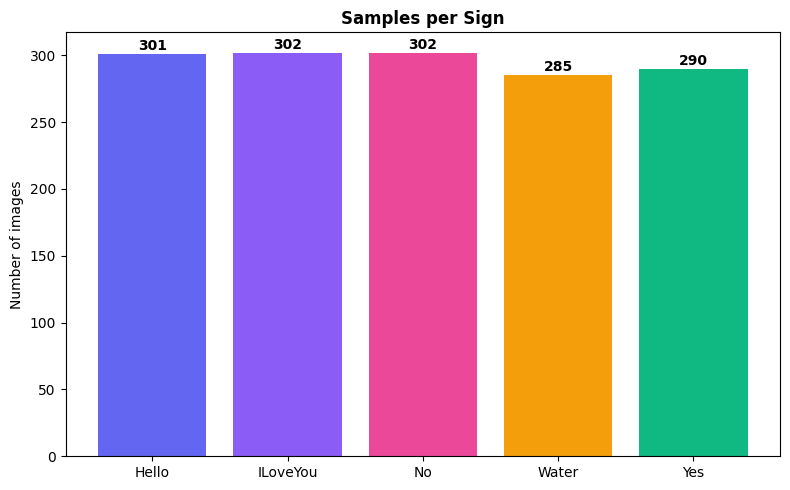

In [7]:
import os, matplotlib.pyplot as plt

counts = {}
for d in sorted(os.listdir(DATA_DIR)):
    full = os.path.join(DATA_DIR, d)
    if os.path.isdir(full):
        counts[d] = len(os.listdir(full))

plt.figure(figsize=(8,5))
bars = plt.bar(counts.keys(), counts.values(),
               color=['#6366f1','#8b5cf6','#ec4899','#f59e0b','#10b981'])
plt.title('Samples per Sign', fontweight='bold')
plt.ylabel('Number of images')
for b, v in zip(bars, counts.values()):
    plt.text(b.get_x()+b.get_width()/2, v+3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/samples_per_sign.png', dpi=150)
plt.show()

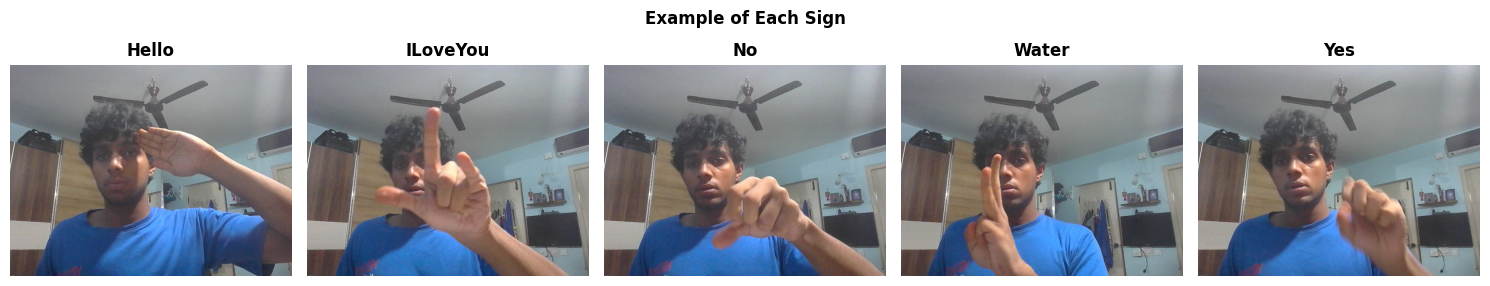

In [8]:
import matplotlib.image as mpimg

plt.figure(figsize=(15,3))
for i, d in enumerate(sorted(counts.keys())):
    folder = os.path.join(DATA_DIR, d)
    first_img = sorted(os.listdir(folder))[0]
    img = mpimg.imread(os.path.join(folder, first_img))
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(d, fontweight='bold')
    plt.axis('off')
plt.suptitle('Example of Each Sign', fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/example_signs.png', dpi=150)
plt.show()

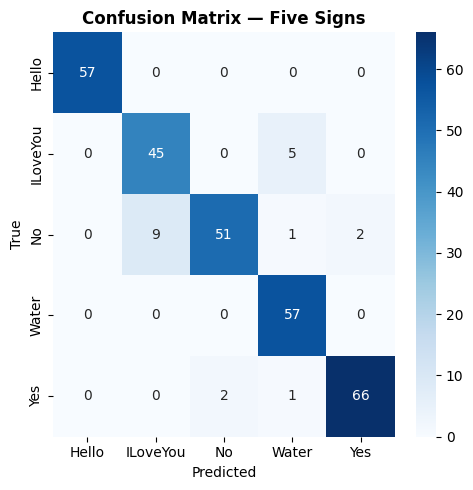

In [14]:
import numpy as np, seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Five Signs', fontweight='bold')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()